# Financial Econometrics I - Project
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)

**Note**: RV is provided as Realized Volatility. As such, all models are estimated on that scale, unless specified otherwise.

**AI tool usage**: 

**Data used**: `Asset 12`

---

## Setup

In [1]:
library(xts)
library(forecast) 
library(rugarch)
library(lmtest)
library(sandwich)

options(repr.plot.width = 12, repr.plot.height = 7)

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: parallel



In [2]:
#Loading data
load("12.RData")

dates <- as.Date(index(adp))
df <- data.frame(date = dates, coredata(adp)) #xts to df for regressions
n <- nrow(df)

str(df)
head(df, 3)
tail(df, 1)
colSums(is.na(df))

'data.frame':	1500 obs. of  7 variables:
 $ date: Date, format: "2010-01-05" "2010-01-06" ...
 $ ret : num  -0.02065 0.00351 -0.01578 0.00686 0 ...
 $ RV  : num  0.00735 0.00726 0.00825 0.01071 0.00819 ...
 $ RV_p: num  0.00541 0.00527 0.00638 0.00832 0.00587 ...
 $ RV_n: num  0.00498 0.00499 0.00522 0.00674 0.00572 ...
 $ RS  : num  0.14174 0.37146 0.63841 0.82536 -0.00218 ...
 $ RK  : num  4.47 4.65 5.18 8.59 3.6 ...


,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2010-01-05,-0.02065318,0.007350539,0.005405043,0.004981559,0.1417402,4.466892
2,2010-01-06,0.00351129,0.007256418,0.005266342,0.004992118,0.3714606,4.651872
3,2010-01-07,-0.01577893,0.008245743,0.006380770,0.005222840,0.6384128,5.184831


,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1500,2016-01-22,0.02683273,0.01078354,0.008042433,0.007183591,0.3585356,3.632521


date  ret   RV RV_p RV_n   RS   RK 
   0    0    0    0    0    0    0

---
# 1. Data Description

The dataset contains 1,500 daily observations of Asset 12 over time period of January 5, 2010 through January 22, 2016. Six variables are included: returns (ret), realized volatility (RV), positive realized semi-volatility (RV_p) and negative realized semi-volatility (RV_n), realized skewness (RS) and realized kurtosis (RK). No data is missing.

## Descriptive Statistics

In [3]:
vars <- c("ret", "RV", "RV_p", "RV_n", "RS", "RK")

#Functions for sample skewness and excess kurtosis
skew <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  n / ((n - 1) * (n - 2)) * sum(((x - x_bar) / s)^3) #bias corrected skew
}

kurt <- function(x) {
  n <- length(x)
  x_bar <- mean(x)
  s <- sd(x)
  
  term1 <- (n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3)) #bias correction factor
  term2 <- 3 * (n - 1)^2 / ((n - 2) * (n - 3)) #bias corrected version of -3
  
  term1 * sum(((x - x_bar) / s)^4) - term2 #excess kurtosis
}

desc <- data.frame(
  variable = vars,
  min = sapply(vars, function(v) min(df[[v]])),
  mean = sapply(vars, function(v) mean(df[[v]])),
  median = sapply(vars, function(v) median(df[[v]])),
  max = sapply(vars, function(v) max(df[[v]])),
  sd = sapply(vars, function(v) sd(df[[v]])),
  skewness = sapply(vars, function(v) skew(df[[v]])),
  ex_kurt = sapply(vars, function(v) kurt(df[[v]])),
  n = sapply(vars, function(v) sum(!is.na(df[[v]])))
)
round(desc[, -1], 5)

,min,mean,median,max,sd,skewness,ex_kurt,n
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ret,-0.13124,0.00052,0.00072,0.06243,0.01258,-0.93020,11.43632,1500
RV,0.00333,0.00888,0.00807,0.09567,0.00434,8.34182,138.23081,1500
RV_p,0.00170,0.00624,0.00572,0.09320,0.00339,12.61247,295.39560,1500
RV_n,0.00168,0.00618,0.00554,0.05952,0.00300,5.37825,72.71287,1500
RS,-8.11384,0.01118,0.01638,6.62202,1.12760,-0.38673,5.01832,1500
RK,2.15327,6.11569,4.61776,69.69763,4.90279,4.87688,38.27971,1500


The **returns** are close to zero mean and are negatively skewed with positive excess kurtosis. This is common when describing the characteristics of financial returns. **Realized Volatility (RV)** appears to be right skewed; the mean is greater than the median. The two realized semi-variabilities **(RV_p & RV_n)** have nearly identical means in this example, although they differ substantially in higher moments. **Realized Skewness (RS)** is centered close to zero, however, it can range anywhere from approximately (-8) to (+6) - extreme skewness is more severe on the negative side. **Realized Kurtosis (RK)** is generally well above 3 and is also highly right skewed. Fat-tailed intraday distributions appear to be the norm. Some days have extreme tail behaviour reaching as high as 69.7.

## Time Series Plots

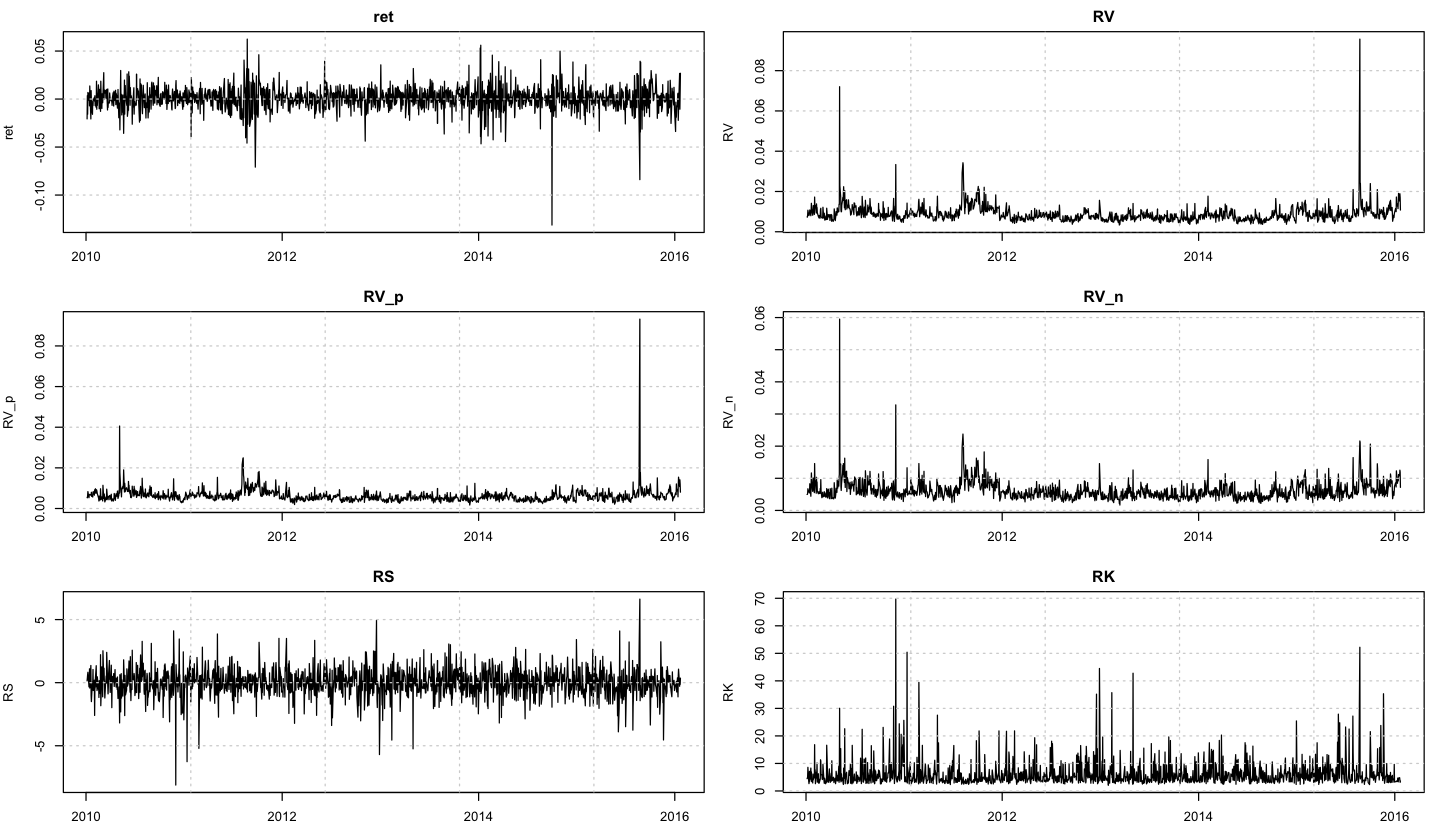

In [4]:
par(mfrow = c(3, 2), mar = c(3, 4, 2, 1))
for (v in vars) {
  plot(df$date, df[[v]], type = "l", main = v, xlab = "", ylab = v)
  grid()
}

The evidence from RV clearly demonstrates that the returns exhibit **"volatility clustering"** (i.e., periods of calm markets and those of turbulence) and that periods of high volatility in the returns typically remain for a number of weeks. Visually, the returns appear to be stationary; however, they do occasionally experience severe negative shocks. **RV** exhibits 2-4 sharp temporary spikes, which return to base levels rather quickly. The behaviour of both **RV_p and RV_n** appears very similar. Nevertheless, it is evident that the most negative and most positive volatility spikes, do not occur at the same time. **RS** does not portray evident/clear clusters and fluctuates around 0. **RK**: there seems to be some correlation between RK and RV spikes. RK, which appears to be consistently above 3, exhibits numerous spikes along the sample, with the most extreme one falling within a positive net return day, as it can be seen below.

In [5]:
df[which.max(df$RK), ]

,date,ret,RV,RV_p,RV_n,RS,RK
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
228,2010-12-01,0.0142171,0.03337935,0.006029963,0.03283017,-8.113845,69.69763


## ACF Plots

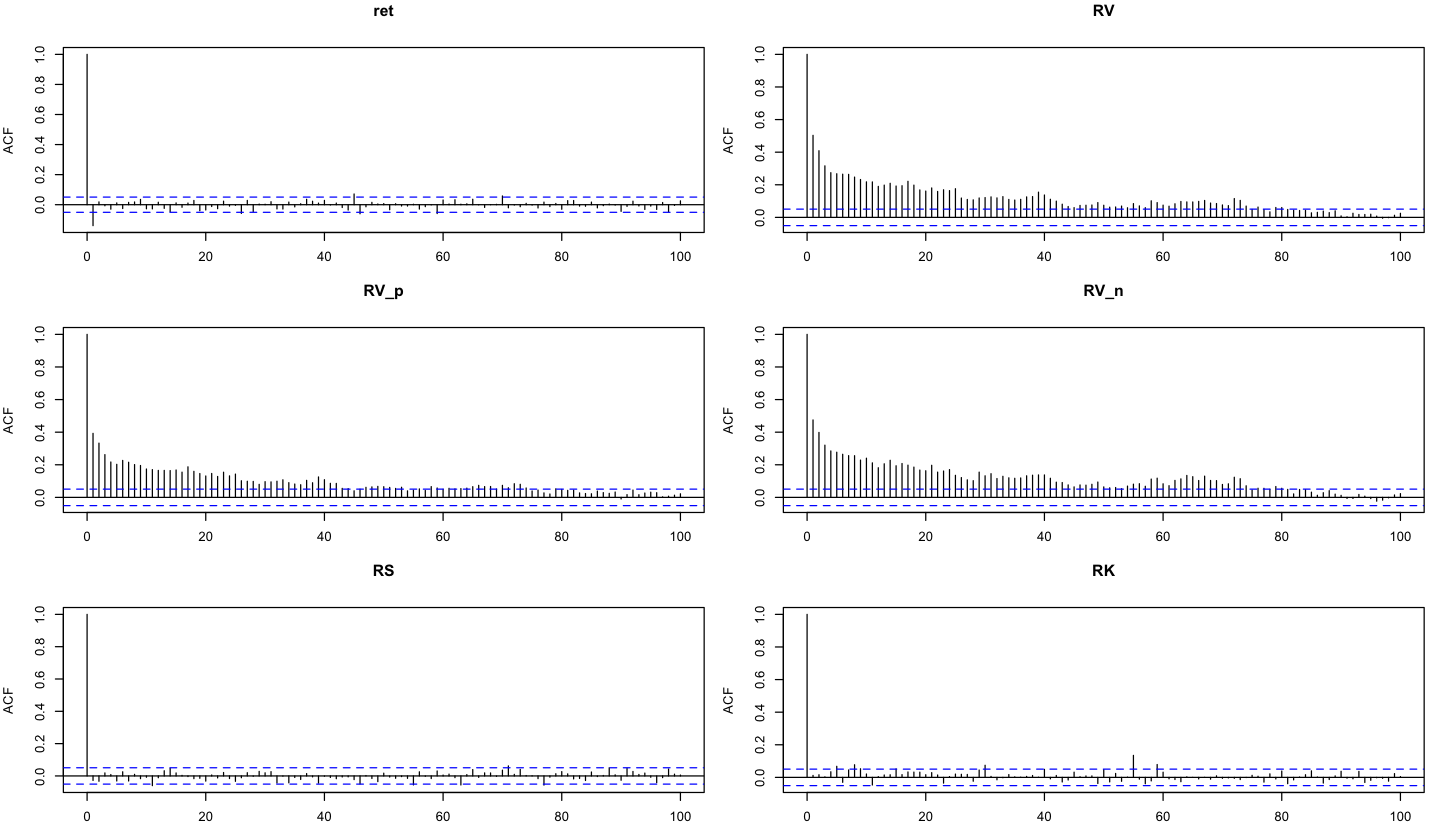

In [6]:
par(mfrow = c(3, 2), mar = c(3, 4, 3, 1))
for (v in vars) {
  acf(df[[v]], lag.max = 100, main = paste(v))
}

**Returns** demonstrate almost no serial correlation at any lag (mostly lag 1), which is consistent with weak form market efficiency. **RV, RV_p, and RV_n** demonstrate a strong autocorrelation that is relatively slow to decay (long memory). This suggests the presence of persistent volatility dynamics that motivates the use of the HAR (Heterogeneous Autoregressive) model. The **RS** ACF confirms no clustering as hypothesized - it is close to white noise with nearly no autocorrelation. **RK** does not seem to portray systematic autocorrelation, with several lags crossing the significance level rather arbitrarily. 

## Histograms & Density

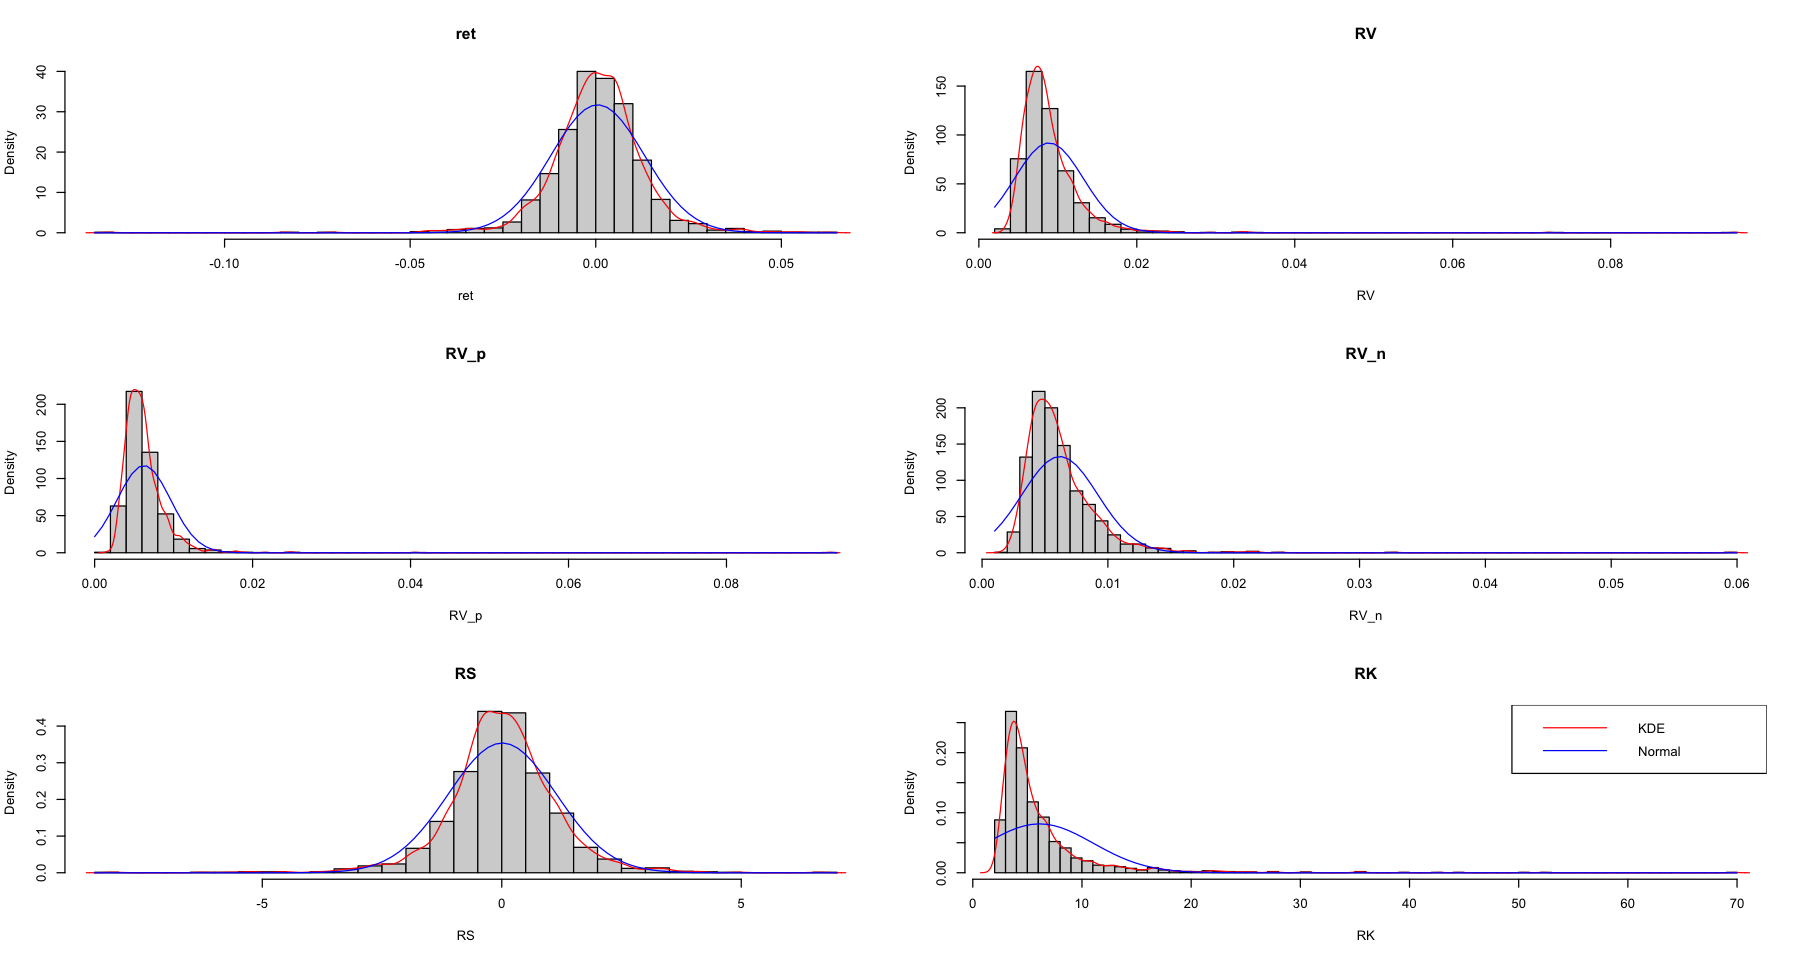

In [7]:
options(repr.plot.height = 8, repr.plot.width = 15)
par(mfrow = c(3, 2))

for (v in vars) {
  hist(df[[v]], breaks = 50, main = v, xlab = v, freq = FALSE)
  lines(density(df[[v]]), col = "red")
  curve(dnorm(x, mean = mean(df[[v]]), sd = sd(df[[v]])),
    add = TRUE, col = "blue")
}

legend("topright", legend = c("KDE", "Normal"),
  col = c("red", "blue"), lty = 1)

The **returns** appear to be rather close to normally distributed; however, they have "fatter tails" than a true normal distribution (which corresponds to the excess kurtosis reported in the descriptive statistics). All **three RV metrics** are skewed toward the right with an extended tail - i.e., most of the time, intraday volatilities are relatively low, but from time-to-time, volatility spikes significantly. **RS** appears to be approximately symmetrical around zero but it is more heavily tailed than a normal ( substantial intra-day skewness occurs at times). **RK** is centered around 3-5, but it also has a significant amount of mass in its `upper-`right tail`, with very large outliers. Normal distribution is a poor fit overall.

# 2. In-Sample Fit

We estimate **six volatility models** on all of our sample data. Our HAR family models have $RV_t$ (Realized Volatility) as their dependent variable. Our GARCH family models measure the Conditional Variance ($h_t$) of stock returns. Their $\sigma_t=sqrt(h_t)$ can therefore be directly compared against $RV_t$.

## Constructing Regressors

The HAR family has three measures of how long past volatilities continue in some form of past behavior. Those are **daily**, **weekly** (a 5-day average) and **monthly** (a 22-day average). All regressors are lagged by one day to ensure we use only information available at time $t-1$.

In [8]:
#Extracting the variables used in the models
RV <- df$RV
ret <- df$ret
RV_p <- df$RV_p
RV_n <- df$RV_n
RS <- df$RS
RK <- df$RK

#Function for trailing moving averages
ma <- function(x, k) {
  as.numeric(stats::filter(x, rep(1 / k, k), sides = 1))
}

#Weekly & monthly averages
RV_w <- ma(RV, 5)
RV_m <- ma(RV, 22)

RVp_w <- ma(RV_p, 5)
RVp_m <- ma(RV_p, 22)

RVn_w <- ma(RV_n, 5)
RVn_m <- ma(RV_n, 22)

RS_w <- ma(RS, 5)
RS_m <- ma(RS, 22)

RK_w <- ma(RK, 5)
RK_m <- ma(RK, 22)


#Starting from observation 23 because the 22-day average needs enough past data
s <- 23

#Regression ready dataset
model_df <- data.frame(
  date = df$date[s:n],
  RV = RV[s:n],
  
  RV_lag1 = RV[(s - 1):(n - 1)], #RV at t, regressors at t-1
  RV_w = RV_w[(s - 1):(n - 1)],
  RV_m = RV_m[(s - 1):(n - 1)],
  
  RVp_lag1 = RV_p[(s - 1):(n - 1)],
  RVn_lag1 = RV_n[(s - 1):(n - 1)],
  RVp_w = RVp_w[(s - 1):(n - 1)],
  RVn_w = RVn_w[(s - 1):(n - 1)],
  RVp_m = RVp_m[(s - 1):(n - 1)],
  RVn_m = RVn_m[(s - 1):(n - 1)],
  
  RS_lag1 = RS[(s - 1):(n - 1)],
  RS_w = RS_w[(s - 1):(n - 1)],
  RS_m = RS_m[(s - 1):(n - 1)],
  
  RK_lag1 = RK[(s - 1):(n - 1)],
  RK_w = RK_w[(s - 1):(n - 1)],
  RK_m = RK_m[(s - 1):(n - 1)],
  
  ret_lag1 = ret[(s - 1):(n - 1)])

model_df <- na.omit(model_df)

nrow(model_df)

[1] 1478

## Model 1: AR(1)-RV

$$RV_t = \beta_0 + \beta_1\, RV_{t-1} + \varepsilon_t$$

In [9]:
m1 <- lm(RV ~ RV_lag1, data = model_df)

summary(m1)


Call:
lm(formula = RV ~ RV_lag1, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.028461 -0.001651 -0.000438  0.000946  0.081357 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.004398   0.000222   19.81   <2e-16 ***
RV_lag1     0.503519   0.022485   22.39   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003767 on 1476 degrees of freedom
Multiple R-squared:  0.2536,	Adjusted R-squared:  0.2531 
F-statistic: 501.5 on 1 and 1476 DF,  p-value: < 2.2e-16


The **AR(1) coefficient** on the lagged RV is nearly **0.50** and highly significant. Thus, we can see a large/moderate amount of day-to-day persistence in volatility. We find an adjusted R² of approximately **0.25** - a quarter of the variance in the current day's volatility is explained by the previous day's volatility. This is the simplest baseline.

## Model 2: HAR-RV

$$RV_t = \beta_0 + \beta_d\, RV_{t-1} + \beta_w\, RV_{t-1}^{(w)} + \beta_m\, RV_{t-1}^{(m)} + \varepsilon_t$$

In [10]:
m2 <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

summary(m2)


Call:
lm(formula = RV ~ RV_lag1 + RV_w + RV_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018237 -0.001543 -0.000375  0.000985  0.082325 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0016237  0.0003591   4.521 6.63e-06 ***
RV_lag1     0.3226509  0.0299412  10.776  < 2e-16 ***
RV_w        0.1932316  0.0529429   3.650 0.000272 ***
RV_m        0.3015702  0.0582013   5.181 2.51e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003641 on 1474 degrees of freedom
Multiple R-squared:  0.3036,	Adjusted R-squared:  0.3022 
F-statistic: 214.2 on 3 and 1474 DF,  p-value: < 2.2e-16


Because in HAR models the rolling weekly ($RV_t^{(w)}$) and monthly ($RV_t^{(m)}$) averages overlap over consecutive periods, this makes the OLS residuals exhibit serial correlation. As such, the standard errors are biased. We correct for this using Newey West standard errors at lag 22 (the largest lag in the model).

In [11]:
NW2 <- NeweyWest(m2, lag=22)
coeftest(m2, vcov=NW2)



t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.00162372 0.00034949  4.6459 3.687e-06 ***
RV_lag1     0.32265093 0.04945564  6.5240 9.383e-11 ***
RV_w        0.19323161 0.04945005  3.9076 9.744e-05 ***
RV_m        0.30157015 0.05686121  5.3036 1.308e-07 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


We find all of these components of volatility persistence to be **statistically significant**. The daily lagged term provides the largest contribution to volatility persistence (approximately 0.32). It represents a measure of short-term persistence in volatility. Next, we find the weekly average term contributing a smaller portion of total variability in volatility (around 0.19). Therefore, it provides evidence of medium-term volatility clustering. Lastly, we also indentify the monthly average term to be statistically significant with a coefficient of approximately 0.30. Finally, we can see a meaningful increase in the adjusted R² to around 0.30, which indicates volatility persistence occurring on multiple time scales simultaneously.

## Model 3: HAR-RS (Realized Semivariances)

We use positive (RV_p) and negative (RV_n) semi-volatility for each of our three time horizons based on Patton & Sheppard (2015). In our data, RV_p and RV_n are semi-volatilities (not variances) – they satisfy $RV_p^2 + RV_n^2 = RV^2$ rather than summing to RV directly. This segmentation allows the predictive power of upside versus downside movements to be different for future volatility. 

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)} + \varepsilon_t$$

In [12]:
m3 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df)

summary(m3)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.015436 -0.001529 -0.000345  0.000964  0.082062 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0014300  0.0003587   3.986 7.04e-05 ***
RVp_lag1    0.1819176  0.0410720   4.429 1.02e-05 ***
RVn_lag1    0.3605367  0.0489478   7.366 2.92e-13 ***
RVp_w       0.0783204  0.1028962   0.761   0.4467    
RVn_w       0.1724096  0.1150019   1.499   0.1340    
RVp_m       0.0193103  0.2012518   0.096   0.9236    
RVn_m       0.3905262  0.2129960   1.833   0.0669 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.003602 on 1471 degrees of freedom
Multiple R-squared:  0.3197,	Adjusted R-squared:  0.317 
F-statistic: 115.2 on 6 and 1471 DF,  p-value: < 2.2e-16


In [13]:
NW3 <- NeweyWest(m3, lag=22)
coeftest(m3, vcov=NW3)


t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 0.00143001 0.00027549  5.1908 2.387e-07 ***
RVp_lag1    0.18191759 0.04247937  4.2825 1.968e-05 ***
RVn_lag1    0.36053667 0.09115347  3.9553 8.009e-05 ***
RVp_w       0.07832040 0.09287277  0.8433   0.39919    
RVn_w       0.17240962 0.10713041  1.6093   0.10776    
RVp_m       0.01931026 0.13857214  0.1394   0.88919    
RVn_m       0.39052622 0.16106421  2.4247   0.01544 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


The daily negative semi-volatility coefficient of around 0.36 is approximately double that of its positive counterpart (0.18), each of which is statistically significant. Both results align with a **leverage-type asymmetry**; large down-side movements generally forecast larger subsequent volatilities relative to corresponding up-side movements. At longer horizons, weekly and monthly terms, the coefficients keep the same sign pattern (negative semivariances having a higher coefficient), although only the monthly negative semivariance reaches statistical significance at the 5% level (the only change in significance after implementation of NW se). This pattern suggests that accumulated downside variance over longer horizons has independent predictive power for future volatility, while the weekly horizon split (neg. and pos. RV) appears redundant once daily and monthly coefficients are accounted for. Adjusted $R^2$ is around 0.32 and thus shows an improvement on the standard HAR. Overall, the semivariance split adds predictive power, although dropping the weekly split and retaining only daily and monthly components could yield a more parsimonious and equally valid model (at least within our sample).

## Model 4: HAR-Rskew-Rkurt

We augment the HAR-RS model with realized skewness and realized kurtosis at daily, weekly, and monthly horizons:

$$RV_t = \beta_0 + \beta_d^{+} RV_{p,t-1} + \beta_d^{-} RV_{n,t-1} + \beta_w^{+} RV_{p,t-1}^{(w)} + \beta_w^{-} RV_{n,t-1}^{(w)} + \beta_m^{+} RV_{p,t-1}^{(m)} + \beta_m^{-} RV_{n,t-1}^{(m)}$$
$$+ \gamma_d RS_{t-1} + \gamma_w RS_{t-1}^{(w)} + \gamma_m RS_{t-1}^{(m)} + \delta_d RK_{t-1} + \delta_w RK_{t-1}^{(w)} + \delta_m RK_{t-1}^{(m)} + \varepsilon_t$$

In [14]:
m4 <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m +
           RS_lag1 + RS_w + RS_m +
           RK_lag1 + RK_w + RK_m, data = model_df)

summary(m4)


Call:
lm(formula = RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
    RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, data = model_df)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.018383 -0.001526 -0.000372  0.000931  0.081691 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.260e-03  6.304e-04   3.584 0.000349 ***
RVp_lag1     1.225e-01  5.777e-02   2.121 0.034052 *  
RVn_lag1     5.140e-01  7.168e-02   7.170 1.19e-12 ***
RVp_w        1.099e-02  1.575e-01   0.070 0.944356    
RVn_w        2.447e-01  1.755e-01   1.394 0.163426    
RVp_m       -1.466e-01  2.937e-01  -0.499 0.617916    
RVn_m        4.678e-01  3.089e-01   1.514 0.130123    
RS_lag1      3.031e-04  1.437e-04   2.109 0.035155 *  
RS_w         2.208e-04  3.808e-04   0.580 0.562158    
RS_m         3.883e-04  7.239e-04   0.536 0.591701    
RK_lag1     -6.980e-05  2.385e-05  -2.926 0.003483 ** 
RK_w        -1.193e-04  5.897e-05  -2.022 0.043319 *  
RK_m    

In [15]:
NW4 <- NeweyWest(m4, lag=22)
coeftest(m4, vcov=NW4)


t test of coefficients:

               Estimate  Std. Error t value Pr(>|t|)   
(Intercept)  2.2596e-03  8.3083e-04  2.7197 0.006611 **
RVp_lag1     1.2255e-01  8.5732e-02  1.4294 0.153099   
RVn_lag1     5.1395e-01  1.9351e-01  2.6559 0.007996 **
RVp_w        1.0992e-02  1.3677e-01  0.0804 0.935952   
RVn_w        2.4469e-01  1.4616e-01  1.6741 0.094331 . 
RVp_m       -1.4655e-01  1.6850e-01 -0.8697 0.384580   
RVn_m        4.6780e-01  1.8774e-01  2.4918 0.012820 * 
RS_lag1      3.0305e-04  3.3111e-04  0.9153 0.360199   
RS_w         2.2080e-04  3.5217e-04  0.6270 0.530774   
RS_m         3.8834e-04  4.5866e-04  0.8467 0.397305   
RK_lag1     -6.9799e-05  3.7857e-05 -1.8437 0.065422 . 
RK_w        -1.1927e-04  6.9040e-05 -1.7275 0.084295 . 
RK_m         4.3984e-05  1.0851e-04  0.4053 0.685287   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In Model 4, NW se lead to the statistical significance of several coefficients to change.

Semivariance coefficients follow a similar pattern as found in HAR-RS, although the positive RV at lag 1 is no longer significant. Montly negative RV is now significant at 5%.

Regarding higher moments, the daily realized skewness coefficient is positive although no longer significant after NW. Weekly and monthly RS coefficients are insignificant. Daily and weekly realized kurtosis coefficients are negative and marginally significant at 10%. Adjusted R² values reach around 0.33, the highest R² value of all the HAR type models (slight improvement over HAR_RS). This indicates that skewness and kurtosis provide some limited additional information on predicting future volatility, above and beyond the semivariance breakdown. At least after correcting for autocorellation in standard errors.

## Model 5: Realized GARCH

The Realized GARCH of Hansen, Huang and Shek (2012) is a joint model. It estimates three equations in total; a return equation, a variance equation that utilizes realized volatility as a feedback mechanism for variance, and an estimation equation (measurement equation) to estimate the parameters of the first two: 

$$
\begin{align}
r_t &= \mu + \sqrt{h_t} z_t \\
\ln(h_t) &= \omega + \alpha_1 \ln(RV_{t-1}^2) + \beta_1 \ln(h_{t-1}) \\
\ln(RV_t^2) &= \xi + \delta \ln(h_t) + \tau(z_t) + u_t \\
\tau(z_t) &= \eta_{11} z_t + \eta_{21}(z_t^2 - 1)
\end{align}
$$

where
- $r_t$ - daily return
- $h_t$ - conditional variance
- $z_t$ - standardized return shock
- $RV_t^2$ - realized variance
- $\tau(z_t)$ - leverage function
- $u_t$ - measurement equation error

In [16]:
real_garch_spec <- ugarchspec(variance.model = list(model = 'realGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder = c(0, 0), include.mean = TRUE)
)

m5 <- ugarchfit(
    real_garch_spec, 
    data = xts(df$ret, order.by = df$date), #original df as rugarch will handle lagging internally
    solver = 'hybrid',
    realizedVol = xts(df$RV, order.by = df$date)
)
m5


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000559    0.000294  1.90234 0.057127
omega  -1.095539    0.310401 -3.52943 0.000416
alpha1  0.754486    0.082849  9.10678 0.000000
beta1   0.469089    0.036340 12.90829 0.000000
eta11  -0.050666    0.006729 -7.53001 0.000000
eta21   0.000766    0.001542  0.49643 0.619588
delta   0.560020    0.050150 11.16683 0.000000
lambda  0.244603    0.004483 54.55665 0.000000
xi      0.177826    0.444332  0.40021 0.689002

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000559    0.000242  2.31571 0.020574
omega  -1.095539    0.613870 -1.78464 0.074319
alpha1  0.754486    0.168181  4.48614 0.000007
beta1

From the Robust SE results:

Persistence = $\beta_1 + \delta \times \alpha_1 = 0.469 + 0.560 \times 0.755 = 0.787$ - confirmation that the process is stationary and mean-reverting (around 79% of today's variance carries over to tomorrow).

$\alpha_1$ coefficient (0.75) is statistically significant and shows that past realized volatility is informative for current conditional variance.

$\beta_1$ (0.47) is also statistically significant and portrays the persistence of past conditional variance.

$\eta_{11}$ of -0.05 shows the significant leverage effect, where negative return shocks are associated with higher realized volatility.

$\delta$ of 0.56 indicates that 1% increase in the conditional variance leads to a 0.56% increase in realized volatility (RV responds less than proportionally to changes in $h_t$).

The significant lambda coefficient (0.24) proves that $RV$ is a noisy proxy for variance $h_t$ and that there is substantial measurement error in $RV$.

## Model 6: ARMA(1,1)-GARCH(1,1)

We model the conditional mean with an ARMA(1,1) process and the conditional variance with a GARCH(1,1) - a return based model. We can then compare its $\sigma = \sqrt(h_t)$ to RV.

In [17]:
arma_garch_spec <- ugarchspec(
    variance.model = list(model='sGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder = c(1, 1), include.mean = TRUE)
)
m6 <- ugarchfit(arma_garch_spec, data = df$ret, solver = 'hybrid')
m6


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000608    0.000250  2.43031 0.015086
ar1    -0.313142    0.197087 -1.58886 0.112093
ma1     0.196962    0.203862  0.96615 0.333967
omega   0.000028    0.000014  2.07877 0.037639
alpha1  0.257523    0.081231  3.17026 0.001523
beta1   0.594541    0.146455  4.05954 0.000049

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000608    0.000282  2.15558 0.031116
ar1    -0.313142    0.228574 -1.36998 0.170692
ma1     0.196962    0.274543  0.71742 0.473117
omega   0.000028    0.000104  0.26890 0.788005
alpha1  0.257523    0.630255  0.40860 0.682832
beta1   0.594541    1.158878  0.51303 0.607929

LogLike

Persistence = $\alpha_1 + \beta_1 = 0.257 + 0.595 = 0.852$, which is bigger than Realized GARCH (0.787). ARMA-GARCH suggests that shocks die out more slowly (estimating from returns only) than in Realized GARCH.

The ARMA terms are both insignificant, so we can derive that mean dynamics do not explain much and returns are close to white noise (or at least 1,1 is not the correct mean specification, consistent with ACF).

The GARCH terms ($\alpha_1$ and $\beta_1$) become insignificant after SE correction.

## Comparison of In-Sample Fits

In [18]:
#MSE, MAE comparison

#need to ensure GARCH and HAR family fitted values are matching
n_drop <- nrow(df) - nrow(model_df) # = 22

fits <- cbind( #in-sample
    sapply(list(m1, m2, m3, m4), fitted),
    as.numeric(sigma(m5)[(n_drop + 1):nrow(df)]), #drop first 22 obs to match model_df
    as.numeric(sigma(m6)[(n_drop + 1):nrow(df)])
)
colnames(fits) <- c("AR(1)-RV", "HAR-RV", "HAR-RS", "HAR-Rskew-Rkurt", "Realized GARCH", "ARMA-GARCH")

actual <- model_df$RV 

comp <- data.frame(
    MSE = colMeans((actual - fits)^2),
    MAE = colMeans(abs(actual - fits)),
    Adj_R2 = c(sapply(list(m1, m2, m3, m4), function(m) summary(m)$adj.r.squared), NA, NA)
)
comp

,MSE,MAE,Adj_R2
,<dbl>,<dbl>,<dbl>
AR(1)-RV,1.417048e-05,0.001927009,0.2530795
HAR-RV,1.322061e-05,0.001811241,0.3022010
HAR-RS,1.291476e-05,0.001786193,0.3169539
HAR-Rskew-Rkurt,1.256556e-05,0.001751102,0.3327009
Realized GARCH,2.337699e-05,0.003732489,NA
ARMA-GARCH,3.943882e-05,0.004278628,NA


`**AR (1)** is the least complex model. It only has an $R^2$ of around 0.25 when including only one lag of RV. Adding weekly and monthly components, as in **HAR-RV**, raises $R^2$ to approximately 0.30. These results indicate volatility persistence exists at more than one frequency.`

`Splitting volatility into positive and negative semi-volatilities, as in HAR-RS, brings a further improvement (around 0.32). The size of the negative semi-volatility effect is larger than the positive semi-volatility effect which is consistent with leverage type asymmetry.`

`**HAR-Rskew-Rkurt** provides the highest in sample $R^2$ (nearly 0.33). The addition of kurtosis terms adds additional information on the top of semivariance split. `

`**Both GARCH** models sit below the HAR family. While GARCH models measure the conditional variance of returns, this is related to RV but not equivalent to it, so their fit to realized RV is naturally weaker.`

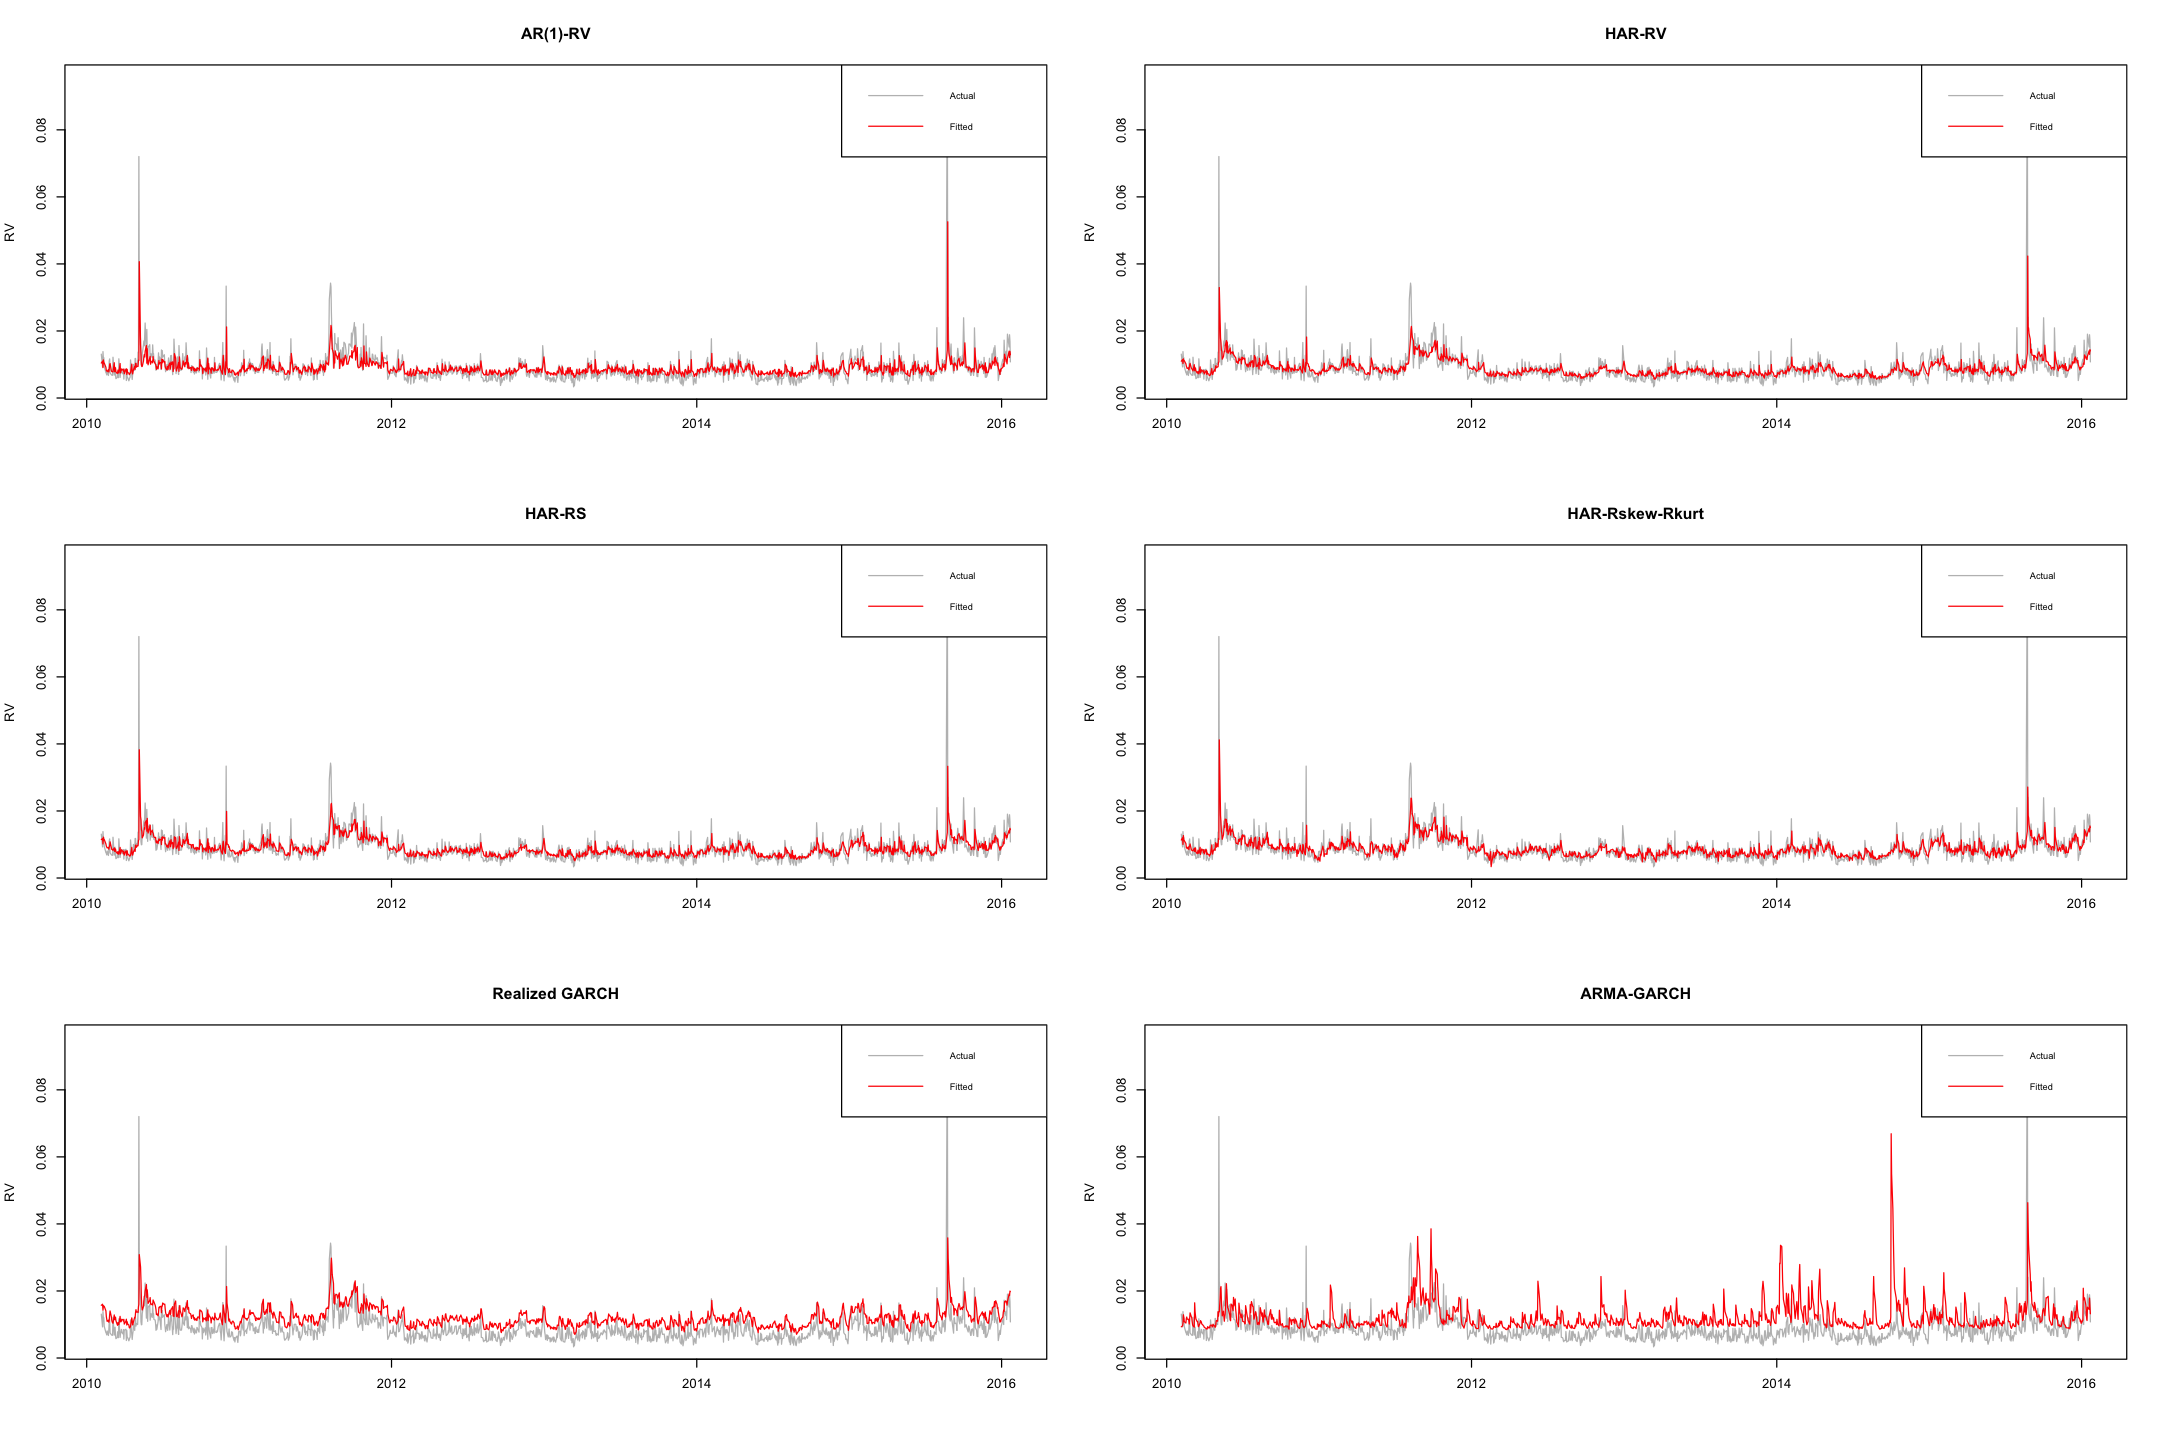

In [19]:
options(repr.plot.height = 12, repr.plot.width = 18)
par(mfrow = c(3, 2))

for (i in seq_along(colnames(fits))) {
  plot(model_df$date, actual, type = "l", col = "grey",
       main = colnames(fits)[i], xlab = "", ylab = "RV")
  lines(model_df$date, fits[, i], col = "red")
  legend("topright", c("Actual", "Fitted"), col = c("grey", "red"), lty = 1, cex = 0.7)
}

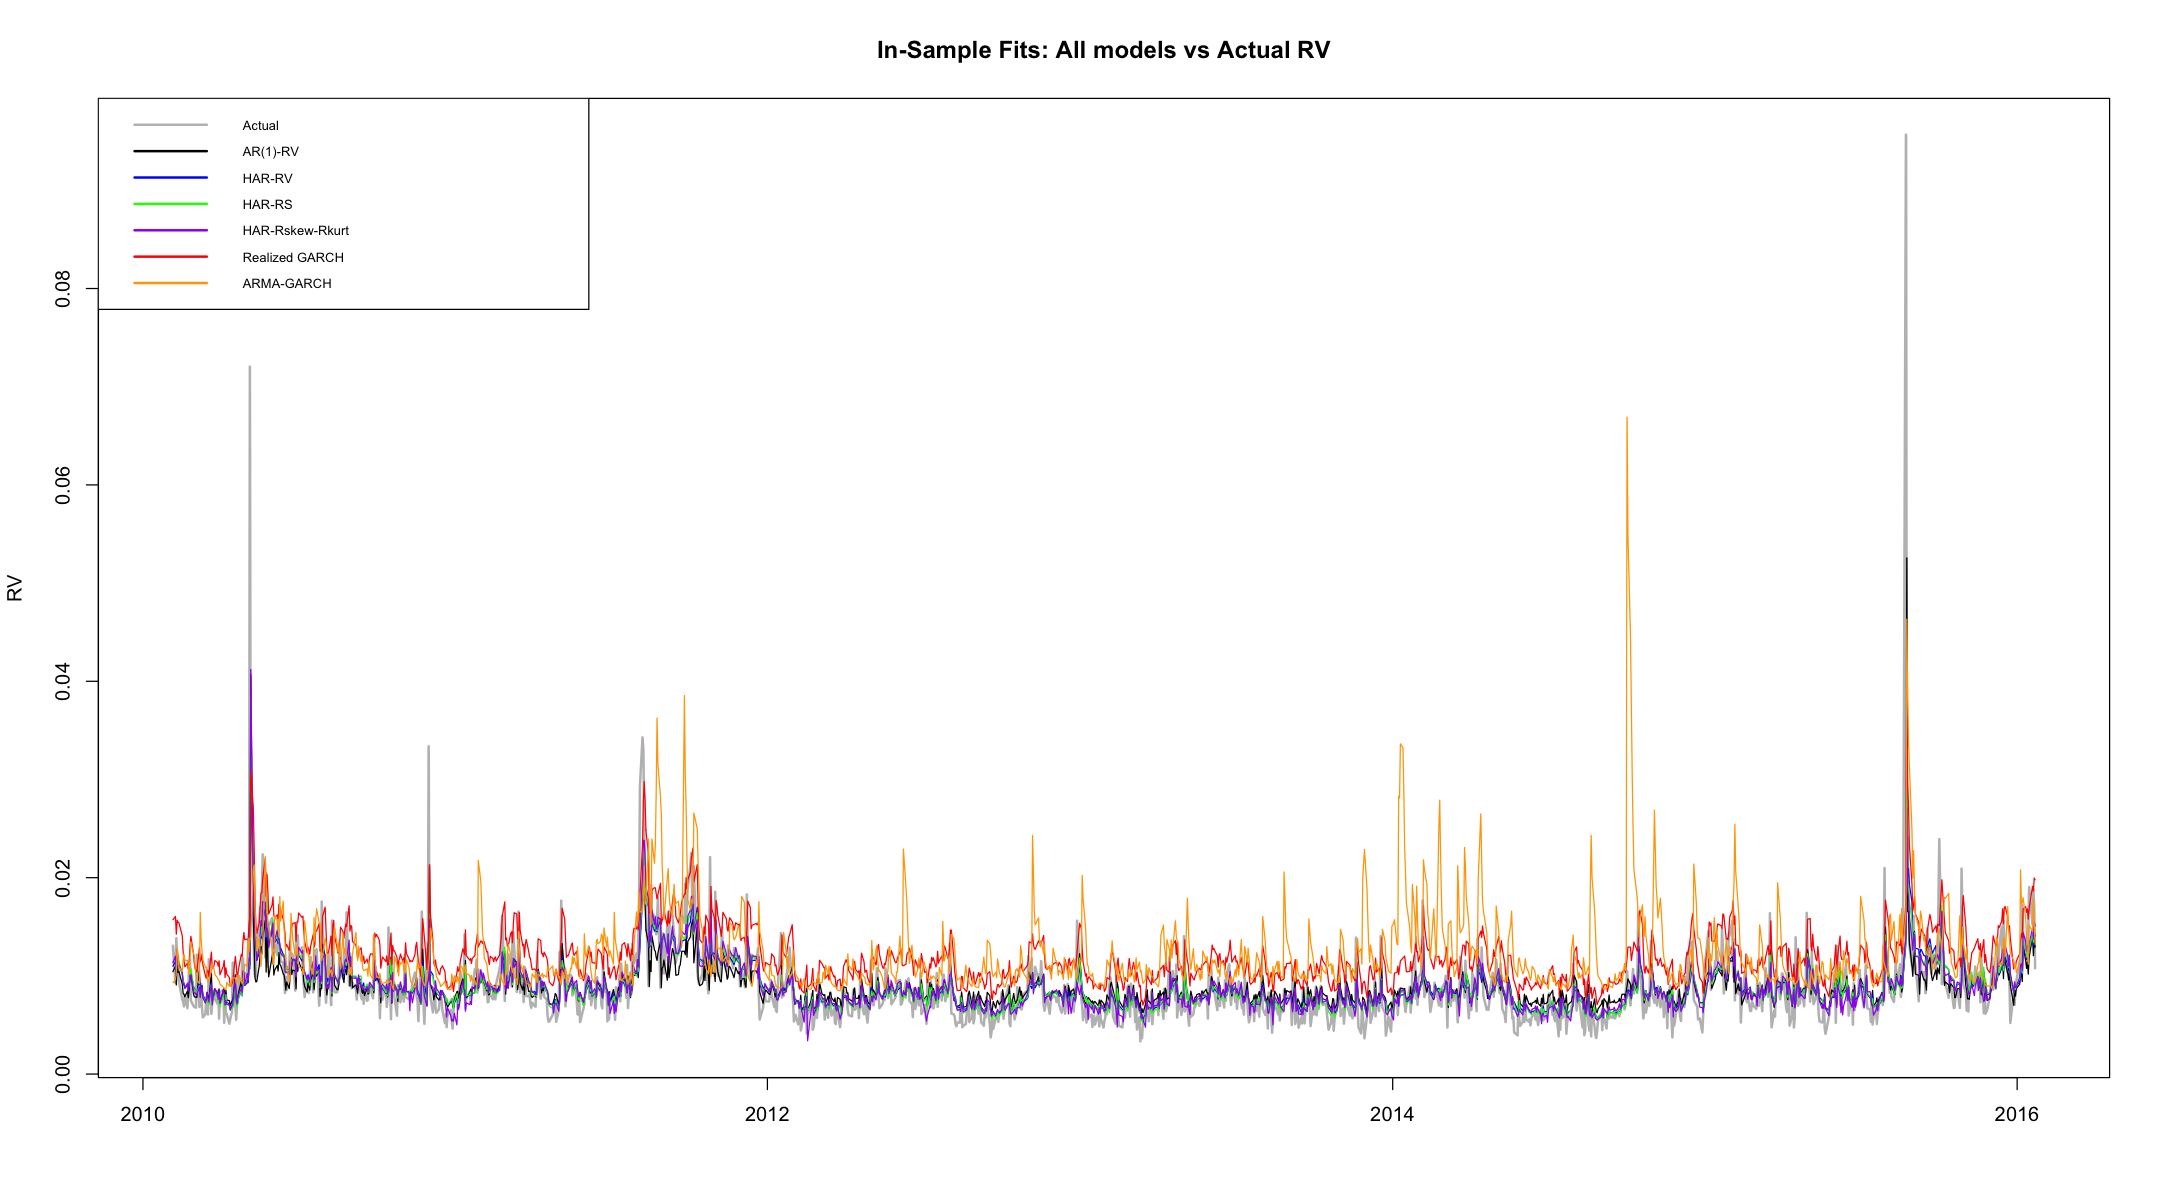

In [20]:
options(repr.plot.height = 10, repr.plot.width = 18)
colors <- c("black", "blue", "green", "purple", "red", "orange")

plot(model_df$date, actual, type="l", col="grey", lwd=2,
    main="In-Sample Fits: All models vs Actual RV",
    xlab="", ylab="RV"
)

for (i in 1:ncol(fits)){
    lines(model_df$date, fits[, i], col=colors[i], lwd=1)
}

legend("topleft", legend=c("Actual", colnames(fits)),
    col=c("grey", colors),
    lwd=c(2), cex=0.65
)

The following patterns can be observed from the plot:

The HAR family models follow closely actual RV during calm periods but consistently undershoot large spikes (smooth out the extreme values). ARMA-GARCH is the most volatile fitted line, which overshoots consistently and significantly, especially in the period 2014-15 (it overreacts to shocks). Furthermore, Realized GARCH and ARMA-GARCH consistently fit values above actual RV.

The HAR models are hardly distinguishable in the plots (confirmed by the similar $R^2$) and fit actual RV more closely than the GARCH family.

Since GARCH family models update conditional variance only from returns, they are slower to react to volatility changes. The HAR family use lagged RV directly and as such respond more quickly to changes in RV levels.

It appears that HAR models track the general level of RV better, but underestimate large volatility spikes on consistent basis. ARMA-GARCH introduces a lot of noise (false spikes). Overall, none of the models capture the largest spikes in volatility accurately. Realized GARCH appears to be the more balanced GARCH model. HAR_Rskew_Rkurt obtains the lowest MSE and MAE of all models.

# 3. Forecasts

## Setup

In [30]:
w_l <- 750 #window len
n_for <- nrow(model_df) - w_l #forecast period

forecast_dates <- model_df$date[(w_l + 1):(nrow(model_df))] #vector of dates
actual_oos <- model_df$RV[(w_l + 1):nrow(model_df)]

#n_for
#length(forecast_dates)
#length(actual_oos)

In [31]:
#Expanding window
#HAR family 
m1_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1, data = model_df[1:(w_l + x - 1), ]) 
    predict(fit, newdata = model_df[w_l + x, ])
})
m2_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})
m3_exp <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})
m4_exp <- sapply(1:n_for, function(x){
    fit <- lm(
        RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
        RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, 
        data = model_df[1:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})
#GARCH family
m5_exp <- ugarchroll(real_garch_spec,
    data = xts(100 * df$ret, order.by = df$date), #scale for convergence
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'recursive',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1,
    realizedVol = xts(100 * df$RV, order.by = df$date)
)
m6_exp <- ugarchroll(arma_garch_spec,
    data = xts(df$ret, order.by = df$date),
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'recursive',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1
)

In [32]:
#Rolling window
#HAR family 
m1_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1, data = model_df[x:(w_l + x - 1), ]) 
    predict(fit, newdata = model_df[w_l + x, ])
})

m2_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RV_lag1 + RV_w + RV_m, data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m3_roll <- sapply(1:n_for, function(x){
    fit <- lm(RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + RVn_m, data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m4_roll <- sapply(1:n_for, function(x){
    fit <- lm(
        RV ~ RVp_lag1 + RVn_lag1 + RVp_w + RVn_w + RVp_m + 
        RVn_m + RS_lag1 + RS_w + RS_m + RK_lag1 + RK_w + RK_m, 
        data = model_df[x:(w_l + x - 1), ])
    predict(fit, newdata = model_df[w_l + x, ])
})

m6_roll <- ugarchroll(arma_garch_spec,
    data = xts(df$ret, order.by = df$date),
    n.ahead = 1,
    forecast.length = n_for,
    refit.window = 'moving',
    window.size = w_l,
    solver = 'hybrid',
    refit.every = 1
)

Warning message in arima(data, order = c(modelinc[2], 0, modelinc[3]), include.mean = modelinc[1], :
“possible convergence problem: optim gave code = 1”
Warning message in arima(data, order = c(modelinc[2], 0, modelinc[3]), include.mean = modelinc[1], :
“possible convergence problem: optim gave code = 1”


In [33]:
# Realized GARCH (manual function) - rugarch does not work (fails to converge)
#Fit all windows and store results
m5_roll_fits <- lapply(1:n_for, function(x) {
    tryCatch(
        ugarchfit(real_garch_spec,
            data = xts(1000 * df$ret, order.by = df$date)[(22 + x):(21 + x + w_l)], #offset by 22 to match model_df (using df since ugarchfit needs xts)
            solver = 'hybrid',
            realizedVol = xts(1000 * df$RV, order.by = df$date)[(22 + x):(21 + x + w_l)] #scale by 1000 due to the severe num. instability
        ),
        error = function(e) NULL
    )
})

Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”
Warning message in .makefitmodel(garchmodel = "realGARCH", f = .realgarchLLH, T = T, :
“
rugarch-->warning: failed to invert hessian
”


In [34]:
#Forecast Realized GARCH
m5_roll_forecast <- sapply(1:n_for, function(x) {
    if(is.null(m5_roll_fits[[x]])) return(NA)
    as.numeric(ugarchforecast(m5_roll_fits[[x]], n.ahead = 1)@forecast$sigmaFor) / 1000
})

length(m5_roll_forecast)

[1] 728

Regarding rolling window Realized GARCH: although forecasts are produced for all windows, the Hessian fails to invert in some subsamples. This results in several abnormal volatility forecast spikes and can therefore be unreliable. The cause is numerical instability inside the rolling windows. The likelihood surface can become too flat for the optimizer to reliably estimate parameter uncertainty.

In [35]:
#Get GARCH forecasts 
m5_exp_forecast <- m5_exp@forecast$density$Sigma / 100 #re-scale back
m6_exp_forecast <- m6_exp@forecast$density$Sigma

#m5_roll_forecast excracted from manual func
m6_roll_forecast <- m6_roll@forecast$density$Sigma

#Put forecasts into matrices
forecasts_exp <- cbind(m1_exp, m2_exp, m3_exp, m4_exp, m5_exp_forecast, m6_exp_forecast)
forecasts_roll <- cbind(m1_roll, m2_roll, m3_roll, m4_roll, m5_roll_forecast, m6_roll_forecast)

colnames(forecasts_exp) <- colnames(forecasts_roll) <- c("AR", "HAR", "HAR-RS", "HAR-RS-RK", "RealGARCH", "ARMA-GARCH")

## Forecast Plots

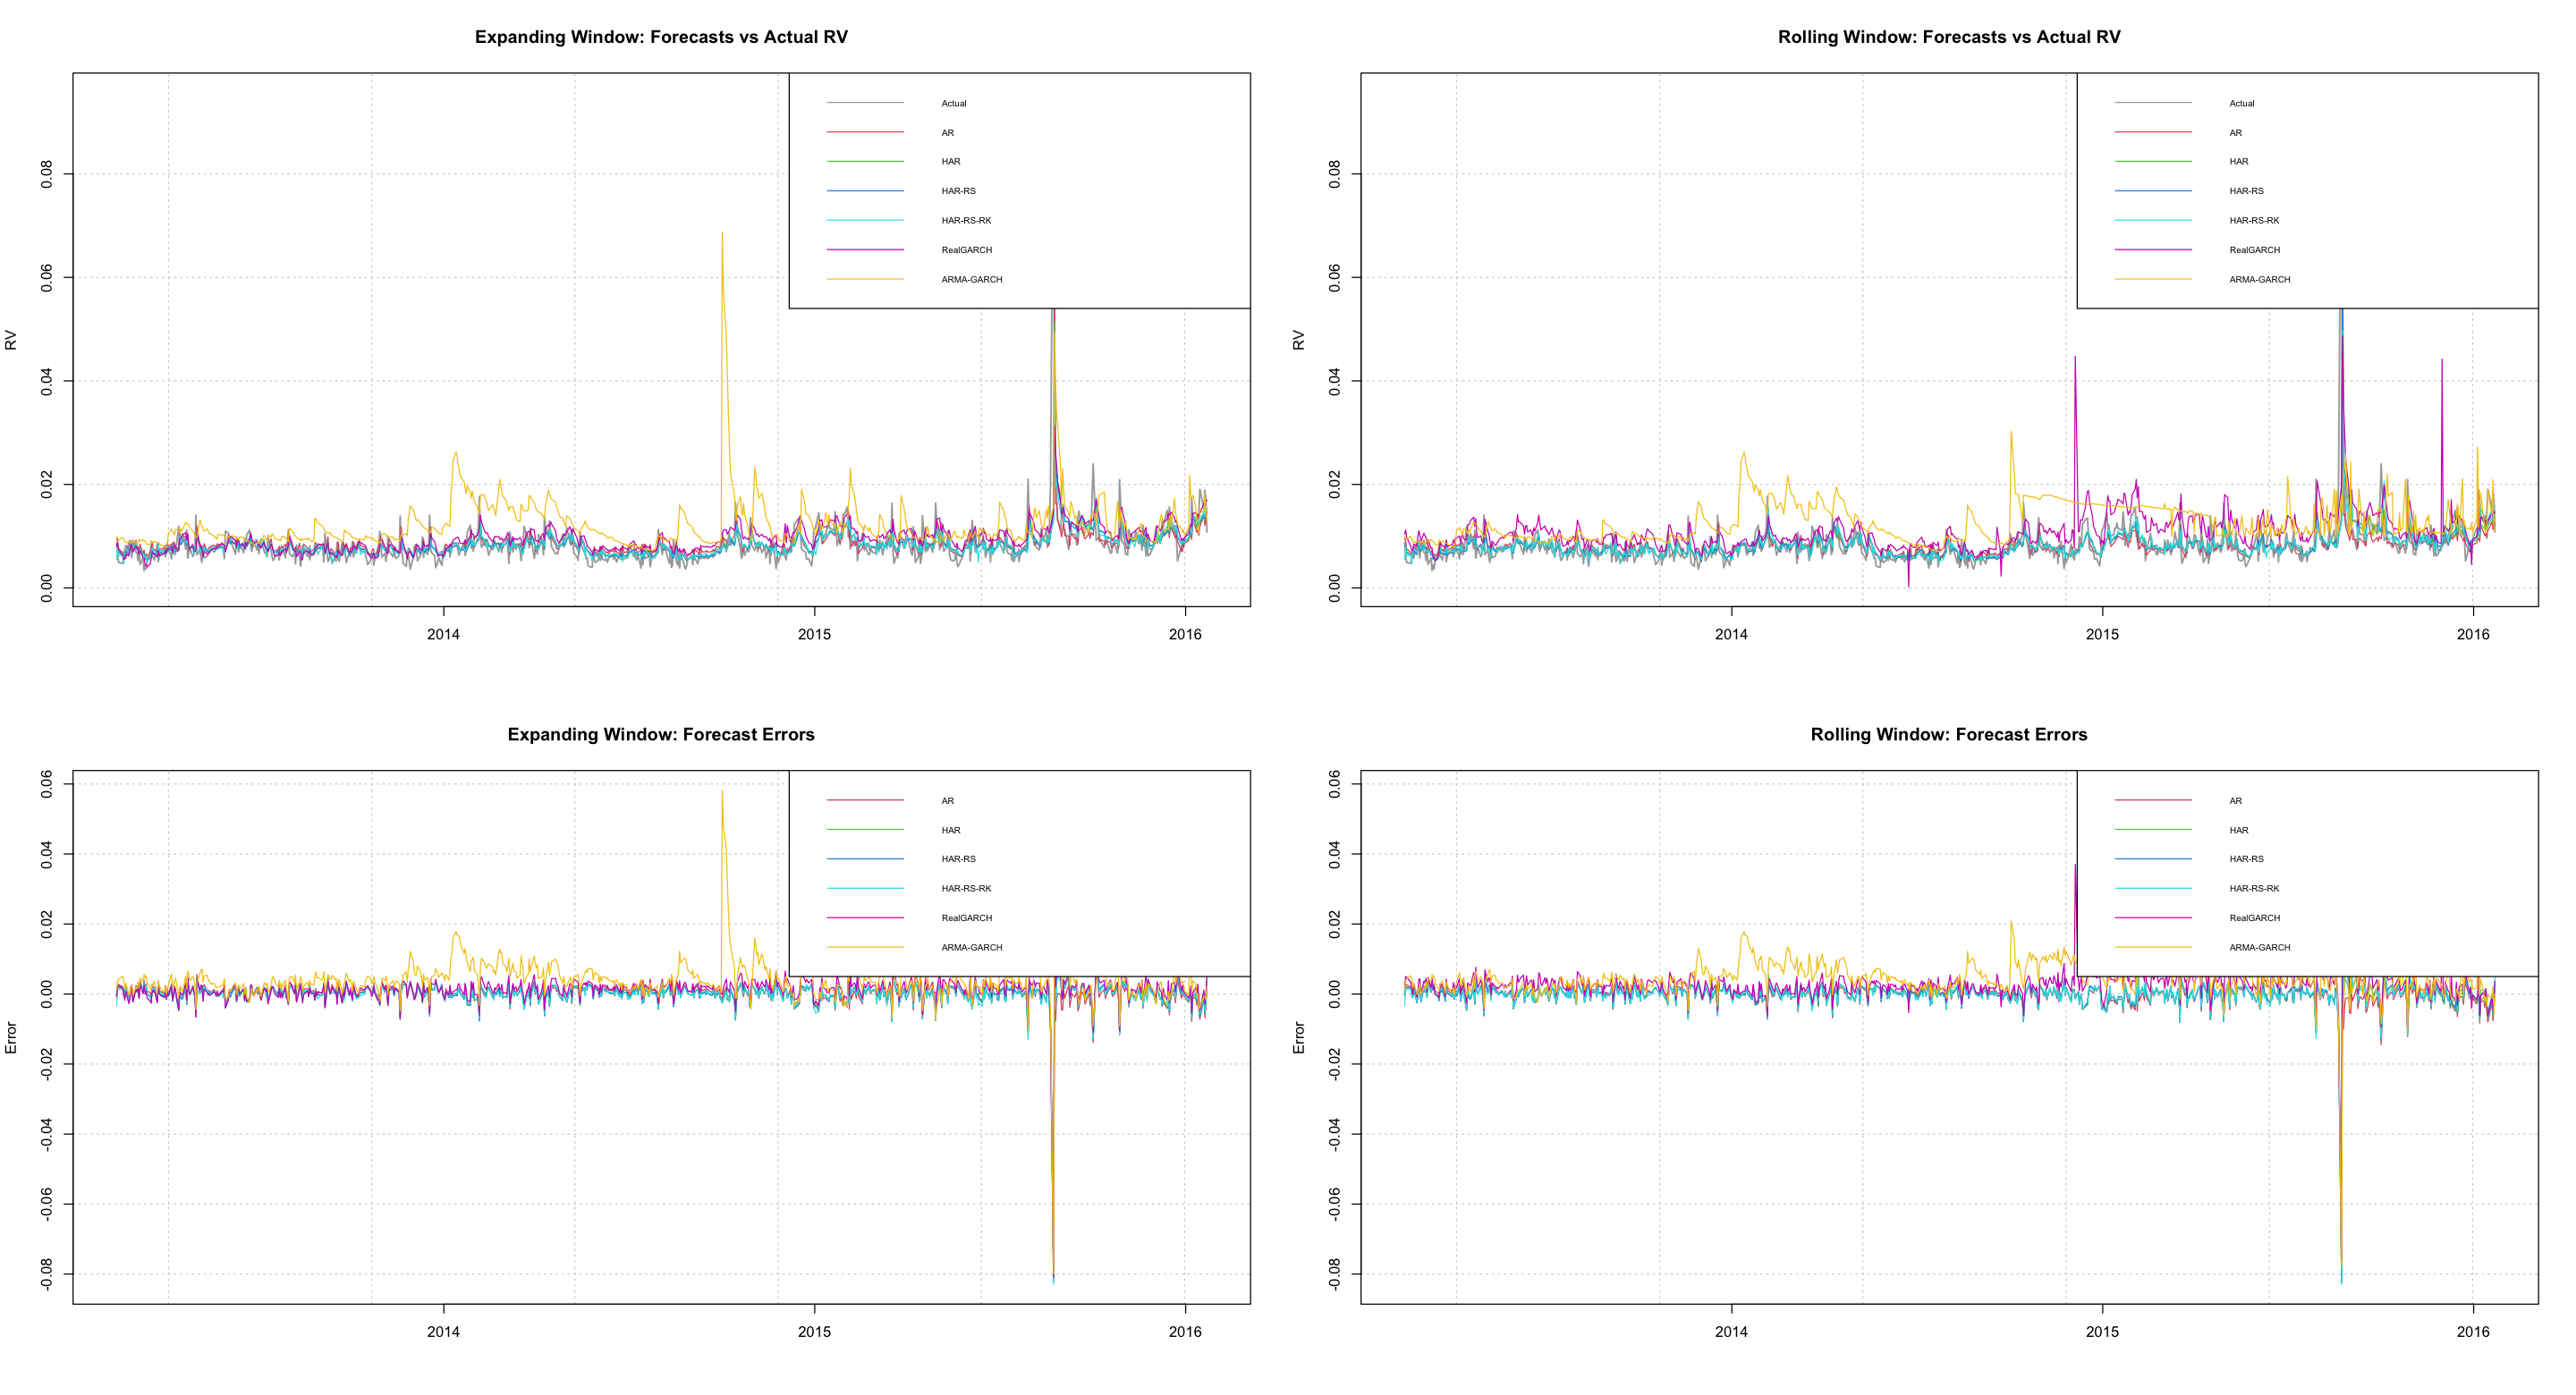

In [36]:
##Actual vs forecast RV
options(repr.plot.height = 13, repr.plot.width = 24)
par(mfrow = c(2, 2))
y_lim <- range(c(actual_oos, forecasts_exp, forecasts_roll))

#Expanding window
plot(forecast_dates, actual_oos, type = "l", col = "darkgrey", lwd = 1.5,
    main = "Expanding Window: Forecasts vs Actual RV",
    xlab = "", ylab = "RV", ylim = y_lim,
    panel.first = grid()
)

for (i in 1:6) lines(forecast_dates, forecasts_exp[, i], col = i + 1, lty = 1)
legend("topright", legend = c("Actual", colnames(forecasts_exp)),
    col = c("darkgrey", 2:7), lty = 1, cex = 0.6
)

#Rolling window
plot(forecast_dates, actual_oos, type = "l", col = "darkgrey", lwd = 1.5,
    main = "Rolling Window: Forecasts vs Actual RV",
    xlab = "", ylab = "RV", ylim = y_lim,
    panel.first = grid()
)

for (i in 1:6) lines(forecast_dates, forecasts_roll[, i], col = i + 1, lty = 1)
legend("topright", legend = c("Actual", colnames(forecasts_roll)),
    col = c("darkgrey", 2:7), lty = 1, cex=0.6, 
)


##Errors plot
errors_exp <- forecasts_exp - actual_oos
errors_roll <- forecasts_roll - actual_oos

#Expanding window
plot(forecast_dates, errors_exp[, 1], type = "l", col = 2,
    main = "Expanding Window: Forecast Errors",
    xlab = "", ylab = "Error", ylim = range(errors_exp, errors_roll),
    panel.first = grid())
for (i in 2:6) lines(forecast_dates, errors_exp[, i], col = i + 1)
legend("topright", legend = colnames(forecasts_exp), col = 2:7, lty = 1, cex = 0.6)

#Rolling window
plot(forecast_dates, errors_roll[, 1], type = "l", col = 2,
    main = "Rolling Window: Forecast Errors",
    xlab = "", ylab = "Error", ylim = range(errors_exp, errors_roll),
    panel.first = grid())
for (i in 2:6) lines(forecast_dates, errors_roll[, i], col = i + 1)
legend("topright", legend = colnames(forecasts_roll), col = 2:7, lty = 1, cex = 0.6)

In [37]:
which(m5_roll_forecast > 0.05)
model_df$date[w_l + which(m5_roll_forecast > 0.05)]

integer(0)

Date of length 0

The general pattern which can be observed from the plots is that all models track RV reasonably well in calm periods. 

The AR(1)-RV model, while being the most parsimonious, it generates volatility forecasts close to the actual ones. A benefit of it is that it does not appear to forecast spurious spikes like ARMA-GARCH or Realized GARCH (in the rolling window scheme).

The HAR family stays consistently close to actual RV observations in both rolling and expanding windows, although the fit in the expanding window scheme is visibly tighter.

We observe that ARMA-GARCH consistently overestimates RV and can forecast sudden spurious spikes (end of 2014) regardless of the estimation window scheme. When actual RV spikes abnormally, ARMA-GARCH underestimates it significantly (second half of 2015). Overall, ARMA-GARCH visibly underperforms the HAR family in both schemes.

Realized GARCH generates forecasts close to actual RV for most of the oos period (especially under the expanding window scheme). As such, in the expanding window scheme, it is a close competitor to the HAR family models. In the rolling window however, due to numerical instability (flat likelihood surface) it produces extreme forecast spikes (2014-01-15 and 2015-12-01), which do not correspond to actual RV shocks. As such, they are purely numerical artifacts rather than viable forecasts.

The expanding window produces more smooth forecasts across all models, while the rolling window can cause erratic volatility forecasts in all models. Since rolling window drops the oldest observation it constantly changes the sample composition - a high volatility observation entering or leaving the sample has a larger effect on the forecast than in the expanding window. Furthermore, the GARCH family appears the most affected by this change in estimation window scheme. Since GARCH models are estimated by MLE, the likelihood function is sensitive to window composition changes, while HAR's OLS is not so affected.


## Loss Functions

In [38]:
#MSE and MAE
mse <- function(actual, forecast) mean((actual - forecast)^2)
mae <- function(actual, forecast) mean(abs(actual - forecast))

#Loss matrices
loss_exp <- apply(forecasts_exp, 2, function(f) c(MSE = mse(actual_oos, f), MAE = mae(actual_oos, f)))
loss_roll <- apply(forecasts_roll, 2, function(f) c(MSE = mse(actual_oos, f), MAE = mae(actual_oos, f)))

loss_table <- data.frame(
    Scheme = rep(c("Expanding", "Rolling"), each = 6),
    Model = rep(colnames(forecasts_exp), 2),
    MSE = c(loss_exp["MSE", ], loss_roll["MSE", ]),
    MAE = c(loss_exp["MAE", ], loss_roll["MAE", ])
) 
loss_table

Scheme,Model,MSE,MAE
<chr>,<chr>,<dbl>,<dbl>
Expanding,AR,1.638522e-05,0.001895814
Expanding,HAR,1.524939e-05,0.001798269
Expanding,HAR-RS,1.498202e-05,0.001782688
Expanding,HAR-RS-RK,1.463733e-05,0.001748864
Expanding,RealGARCH,1.599006e-05,0.002204338
Expanding,ARMA-GARCH,4.916446e-05,0.004534495
Rolling,AR,1.840468e-05,0.001933167
Rolling,HAR,1.726011e-05,0.001827172
Rolling,HAR-RS,1.736058e-05,0.001823691


**Expanding window**:

Based on both MSE and MAE, HAR-RS-RK is the best model. Due to the inclusion of realized semi-volatility, skewness and kurtosis, the model accounts for the assymmetry and heavy-tails of the volatility distribution more precisely than other models. Each step in the HAR "hierarchy" (from m1 to m4) adds additional useful information. This also leads to the monotonically decreasing MSE and MAE from AR -> HAR-RSkew-Kurt.

Real GARCH ranks above AR on MSE but below it on MAE. (the reason for this is hard to identify visually as RealGARCH has a larger error in the expanding window plot and we would therefore expect it to be  penalized harder by MSE).

ARMA-GARCH is by far the worst ranked model. Since it has no direct access to RV and estimates conditional volatilities based solely on returns, this ranking is unsurprising.
`

**Rolling Window**: 

HAR-RSkew-RKurt still wins on both metrics.

Real GARCH is now the worst performer (based on MSE) due to its instability in the rolling window scheme causing it to forecast extreme values on several occurrences.

ARMA-GARCH appears to be the second worst model (on MSE) and ranks higher than Realized GARCH based on MAE. This is the case as Realized GARCH produces smaller errors on most observations, although its several extreme forecasts (numerical instability spikes) lead it to last place on MSE.

Similar to the expanding windows, the HAR family's rankings are as expected since each next model adds additional valuable information to the previous one: HAR-RSkew-RKurt > HAR-RS > HAR > AR (MAE). HAR-RS ranks below HAR on MSE.

**Window scheme comparison**:
The expanding window dominates rolling for every model except ARMA-GARCH, where rolling appears better on MSE. Real GARCH deteriorates significantly in the rolling window scheme.

## Diebold-Mariano test

The Diebold-Mariano test assesses whether the difference in forecast accuracy between two models is statistically significant. For each pair of models, the test compares their loss series under $H_0$ of equal predictive accuracy:

$$DM = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d}) / T}} \xrightarrow{d} N(0,1)$$

where $\bar{d} = \frac{1}{T}\sum_{t=1}^T d_t$ is the mean loss differential, $d_t = L(\hat{e}_{1,t}) - L(\hat{e}_{2,t})$ is the difference in loss between model 1 and model 2 at time $t$, and $\hat{V}(\bar{d})$ is a HAC estimator of the variance of $\bar{d}$. With MSE, the loss is: $L(\hat{e}_t) = (\hat{RV}_t - RV_t)^2$.

In [39]:
#DM test, pairwise comparisons with MSE loss
pairs <- combn(1:6, 2)

dm_pval_exp <- apply(pairs, 2, function(p)
    dm.test(errors_exp[, p[1]], errors_exp[, p[2]], h = 1, 
            alternative = "two.sided")$p.value)

dm_pval_roll <- apply(pairs, 2, function(p)
    dm.test(errors_roll[, p[1]], errors_roll[, p[2]], h = 1, 
            alternative = "two.sided")$p.value)

In [40]:
##Organize results into a matrix
#empty matrices
models <- colnames(forecasts_exp)
dm_matrix_exp <- matrix("", 6, 6, dimnames = list(models, models)) #rows = model 1, cols = model 2
dm_matrix_roll <- matrix("", 6, 6, dimnames = list(models, models))

#assign to upper triangle
for (k in 1:ncol(pairs)) {
    dm_matrix_exp[pairs[1, k], pairs[2, k]] <- round(dm_pval_exp[k], 3)
    dm_matrix_roll[pairs[1, k], pairs[2,k]] <- round(dm_pval_roll[k], 3)
}

dm_matrix_exp
dm_matrix_roll

,AR,HAR,HAR-RS,HAR-RS-RK,RealGARCH,ARMA-GARCH
AR,,0.296,0.282,0.308,0.845,0
HAR,,,0.249,0.343,0.469,0
HAR-RS,,,,0.424,0.219,0
HAR-RS-RK,,,,,0.035,0
RealGARCH,,,,,,0
ARMA-GARCH,,,,,,


,AR,HAR,HAR-RS,HAR-RS-RK,RealGARCH,ARMA-GARCH
AR,,0.092,0.125,0.244,0.055,0
HAR,,,0.528,0.332,0.015,0
HAR-RS,,,,0.312,0.018,0
HAR-RS-RK,,,,,0,0
RealGARCH,,,,,,0
ARMA-GARCH,,,,,,


~None of the Diebold-Mariano tests reach significance at the 5% level in either scheme. As such, we cannot conclude that any model statistically outperforms another. Nevertheless, some patterns can be observed: The lowest p-values tend to involve ARMA-GARCH. This observation is consistent with what we have observed so far. Within the HAR family, the models are far from being statistically distinguishable. As such, we cannot conclude that extending beyond the AR(1)-RV model statistically improves forecast accuracy out-of-sample. The results are consistent across both schemes.~|

`The pairwise comparison for ARMA-GARCH model in both methods is shown to be strongly significant (essentially zero p-values). Therefore, the return-only model is statistically dominated by each model with a connection to realized volatility, not just numerically worse on the loss functions. Realized GARCH is also significantly less accurate than HAR (p = 0.015), HAR-RS (p = 0.018), and HAR-RS-RK (p < 0.001) in the rolling window method. The result is consistent with our earlier documentation of the instability of realized GARCH’s rolling estimates. On the other hand, realized GARCH is only less accurate than HAR-RS-RK (p = 0.035) in the expanding window method.`

`However, there are no statistical differences in the accuracy of forecasts from different members of the HAR family (the smallest p-value among these is 0.09, while the largest p-value is 0.53). Hence, even though HAR-RS-RK produces lower MSE and MAE in both schemes, we cannot determine whether extension to the AR(1)-RV model results in a statistically significant improvement in the accuracy of forecasts produced outside of the estimation sample. The significant differences run between model families (RV-based vs return-based), not within the HAR family.`

## Mincer-Zarnowitz Regression

The goal of the MZ Regression is to test whether a forecast fully and correctly uses all available information with no systematic bias (i.e. it is efficient):

$$RV_t = \alpha + \beta \hat{RV}_t + \varepsilon_t$$

Under $H_0$ of forecast efficiency, $\alpha = 0$ and $\beta = 1$ (unbiased and correctly scaled).

Since OLS tests $H_0: \beta = 0$, we manually compute a t-statistic to test $H_0: \beta = 1$:

$$t = \frac{\hat{\beta} - 1}{SE(\hat{\beta})}$$

In [41]:
##MZ regressions
mz_exp <- lapply(1:6, function(i) lm(actual_oos ~ forecasts_exp[, i]))
names(mz_exp) <- colnames(forecasts_exp)

mz_roll <- lapply(1:6, function(i) lm(actual_oos ~ forecasts_roll[, i]))
names(mz_roll) <- colnames(forecasts_roll)

#summary table
mz_table <- function(mz_list){
    do.call(rbind, lapply(names(mz_list), function(m){
        coef <- summary(mz_list[[m]])$coefficients
        data.frame(
            Model = m,
            Alpha = round(coef[1, "Estimate"], 4),
            t_alpha0 = round(coef[1, "t value"], 2),
            Beta = round(coef[2, "Estimate"], 3),
            t_beta1 = round((coef[2, "Estimate"] - 1) / coef[2, "Std. Error"], 2), #we want to test against 1, not 0
            R2 = round(summary(mz_list[[m]])$r.squared, 3)
        )
    }))
}

mz_table(mz_exp)
mz_table(mz_roll)

Model,Alpha,t_alpha0,Beta,t_beta1,R2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR,0.0024,4.77,0.692,-5.35,0.166
HAR,0.0017,3.48,0.788,-3.69,0.207
HAR-RS,0.0014,2.82,0.824,-3.02,0.216
HAR-RS-RK,0.0009,1.69,0.890,-1.80,0.228
RealGARCH,0.0005,0.86,0.830,-3.01,0.230
ARMA-GARCH,0.0060,14.64,0.191,-25.92,0.049


Model,Alpha,t_alpha0,Beta,t_beta1,R2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR,0.0040,8.98,0.529,-9.07,0.125
HAR,0.0035,8.10,0.590,-8.35,0.166
HAR-RS,0.0035,8.40,0.579,-8.86,0.169
HAR-RS-RK,0.0022,4.65,0.745,-4.78,0.212
RealGARCH,0.0033,7.31,0.466,-13.61,0.163
ARMA-GARCH,0.0046,8.11,0.295,-16.23,0.059


**Expanding window**:
All models reject $\alpha = 0$ at 5%, except HAR-RS-RK and RealGARCH. The results suggest these two are the only unbiased forecasts. All models reject $\beta = 1$ except HAR-RS-RK, meaning it is the only correctly scaled and efficient forecast model in the expanding window. The rest under-predict RV movements as their $\beta < 1$ (underreact to volatility movements). $R^2$ is highest for RealGARCH and HAR-RS-RK and as such are the most informative. ARMA-GARCH has the lowest $R^2$ and the most extreme $\beta$ and $\alpha$ t-stats, making it the worst performer.

**Rolling window**: All models reject both $\alpha = 0$ and $\beta = 1$ - no model is forecast-efficient. All $\alpha$ values are signif. positive (upward biased) and $\beta$ estimates are below 1. In this scheme, RealGARCH ranks the worst (highest bias and lowest scale, most significantly different from 0 and 1 respectively) due to its numerical instability issues. HAR-RS-RK remains the best performing model with lowest bias, highest beta and highest $R^2$. Altogether, all models perform worse in rolling window scheme with the exception of ARMA-GARCH, which performs better. This better performance in the rolling window scheme is somewhat mysterious. It could be attributed to the model dropping out stale observations, which accumulate in the expanding window and can distort estimates over time, nevertheless the model already downweights old observations exponentially, so stale observations should not have much effect anyhow. The improvement could be sampling noise.

# 4. Summary

Both in-sample and out-of-sample, HAR-RS-RK consistently appears to be the best performing model. It exhibits the largest in-sample $R^2$ across the HAR family, the lowest out-of-sample MSE and MAE, and is the only model which satisfies both Mincer-Zarnowitz conditions ($\alpha = 0$ and $\beta = 1$) in the expanding window scheme. Its performance is due to the inclusion of realized semi-volatility, skewness and kurtosis, which turn out to be valuable explanatory variables, which the rest of the HAR family do not fully account for.

The HAR family models as a whole outperform the GARCH family throughout (in-sample and out-of-sample). Since the HAR family directly models RV (exactly our prediction target), they have an advantage over the GARCH family. GARCH is designed to model conditional variance $h_t$, rather than RV directly. The mismatch between their estimation target and our forecast objective explains their underperformance in this analysis. ARMA-GARCH emerges as the worst performer across all criteria since it only relies on return data and has no direct access to RV. Realized GARCH performs reasonably well oos under the expanding window (better than AR and ARMA-GARCH on MSE), but significantly deteriorates inside the rolling window scheme due to numerical instability.

The in-sample and out-of-sample rankings are more or less consistent. HAR and HAR-RS are almost indistinguishable oos (high p-val. in DM and similar loss functions). These results indicate that adding semi-volatility alone does not significantly improve the forecast accuracy beyond the basic HAR. The expanding window results are better across all models except ARMA-GARCH, where the difference in performance could be due to sampling noise rather than true improvement in forecast accuracy.

`The Diebold-Mariano test supports the differences in performance of each model group. The overall worst performing model family is clearly the ARMA-GARCH in both setups. Realized GARCH model is substantially outperformed by the HAR models in the rolling window. In addition, within the HAR family there is no pairwise difference reaching significance at 5% level. Thus, the consistent ranking of the HAR-RS-RK model as the top model is against its simpler relatives.` All models appear to underreact to RV movements ($\beta < 1$ in MZ) with the exception of HAR-RS-RK in the expanding window scheme. In the rolling window scheme, no model achieves forecast efficiency. The general trend is that almost all models are slightly upward biased in their RV forecasting.